In [1]:
# NOTE: unfortunately depends_on_optional machinery in a submodule prevents autoreload from working for that submodule
%load_ext autoreload
%autoreload 2

In [15]:
#import pyproj
#pyproj_dir = '/home/sbhusha1/.conda/envs/coincident/lib/python3.13/site-packages/pyproj/proj_dir/share/proj'

#pyproj.datadir.set_data_dir(pyproj_dir)

#import common_functions
#import os
import numpy as np

# TODO: consider moving some pieces into coincident library
#import cql2
#import numpy as np
#import pyproj
#import rasterio
#import xarray as xr
#from osgeo import gdal
#from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
#import sliderule
#import glob
#import coincident
#from coincident import pcd_fixtures
#from sliderule import earthdata, icesat2, gedi

In [3]:
gdf = gpd.read_file('/panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs/TX_DesertMountains_B1_2018_processing/GEDI/gedi_aligned.gpkg')

<Axes: >

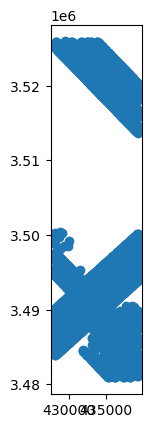

In [4]:
gdf.plot()

In [7]:
from imview import pltlib

[]

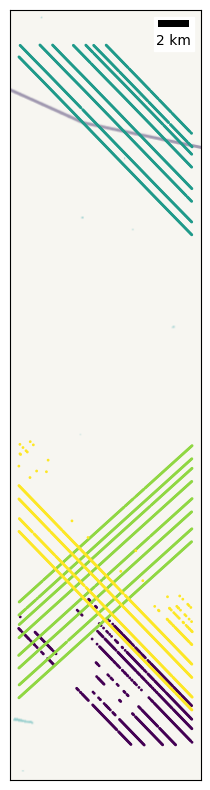

In [12]:
f,ax = plt.subplots(figsize=(10,10))
gdf.plot(ax=ax,column='orbit',markersize=1)
ctx.add_basemap(ax=ax,attribution=False,crs=gdf.crs)
pltlib.add_scalebar(ax=ax,res=1,location='upper right')
ax.set_xticks([])
ax.set_yticks([])

In [6]:
gdf.iloc[0].rh

'[-3.18 -2.95 -2.73 -2.58 -2.43 -2.32 -2.2  -2.09 -1.98 -1.9  -1.83 -1.76\n -1.68 -1.61 -1.57 -1.49 -1.42 -1.38 -1.31 -1.27 -1.23 -1.16 -1.12 -1.08\n -1.04 -0.97 -0.93 -0.89 -0.86 -0.82 -0.78 -0.74 -0.71 -0.67 -0.63 -0.59\n -0.56 -0.52 -0.48 -0.44 -0.41 -0.37 -0.33 -0.29 -0.26 -0.22 -0.18 -0.14\n -0.11 -0.07 -0.03  0.    0.03  0.03  0.07  0.11  0.14  0.18  0.22  0.26\n  0.29  0.33  0.37  0.41  0.44  0.48  0.52  0.56  0.59  0.63  0.67  0.71\n  0.74  0.78  0.82  0.86  0.93  0.97  1.01  1.04  1.12  1.16  1.19  1.27\n  1.31  1.38  1.42  1.49  1.57  1.64  1.72  1.79  1.87  1.98  2.09  2.2\n  2.35  2.5   2.73  2.99  3.48]'

In [11]:
gdf.iloc[0].rh[98]

'-'

In [12]:
np.fromstring(gdf.iloc[0].rh.strip('[]'), sep=' ')[98]+1524.301025	

np.float64(1527.031025)

In [13]:
np.fromstring(gdf.iloc[0].rh.strip('[]'), sep=' ')[100]+1524.301025	

np.float64(1527.781025)

In [20]:
def compute_gedi_surface(row):
    rh_array = np.fromstring(row['rh'].strip('[]'), sep=' ')
    output = row['elevation_lm']+rh_array[100]
    return output

In [21]:
gdf['95_perc'] = gdf.apply(compute_gedi_surface,axis=1)

In [25]:
gdf = gpd.read_file('/panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs/CA_YosemiteNP_2019_processing/GEDI/gedi_aligned.gpkg')

In [26]:
gdf['95_perc'] = gdf.apply(compute_gedi_surface,axis=1)

In [27]:
gdf.describe()

,time,elevation_lm,orbit,solar_elevation,track,sensitivity,beam,flags,elevation_hr,master_frac,energy_total,quality_flag,easting,northing,95_perc
count,4617,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.0,4617.000000,4.617000e+03,4617.000000
mean,2019-10-24 15:54:25.974000,2986.944092,4902.072775,10.620258,3569.150097,0.949717,4.802902,130.070825,2999.899414,0.496777,10560.311523,1.0,281609.165361,4.221631e+06,2999.577639
min,2019-10-06 20:39:14.285000,2294.821289,4626.000000,-31.896362,966.000000,0.900076,0.000000,130.000000,2298.544434,0.000861,3542.270508,1.0,276352.855710,4.215808e+06,2298.961289
25%,2019-10-06 20:39:16.162000,2866.763672,4626.000000,-31.815102,966.000000,0.931350,2.000000,130.000000,2880.598389,0.246441,6188.769531,1.0,278999.627445,4.219263e+06,2880.443799
50%,2019-10-29 11:42:32.068000,2995.889648,4977.000000,12.737232,3812.000000,0.958520,5.000000,130.000000,3008.779785,0.498497,11794.279297,1.0,281355.975441,4.221716e+06,3008.311846
75%,2019-11-05 15:46:06.907000,3104.675293,5088.000000,44.842373,5331.000000,0.968942,8.000000,130.000000,3115.696533,0.742500,14546.886719,1.0,284035.402576,4.224062e+06,3115.438174
max,2019-11-05 15:46:08.345000,3487.668945,5088.000000,44.930965,5331.000000,0.981841,11.000000,131.000000,3501.899170,0.998685,19767.800781,1.0,288302.701832,4.227146e+06,3500.558945
std,NaN,171.498459,200.328932,30.194368,1773.701350,0.022047,3.400181,0.256560,171.020279,0.288311,4340.825684,0.0,3130.390503,2.976116e+03,170.865603
